In [1]:
import json
import time
import tiktoken
import pandas as pd
from google import genai
import os
import re
import glob
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [ ]:

# Configuração da API

API_KEY = ""


client = genai.Client(api_key=API_KEY)
MODEL = "gemini-2.0-flash"  # ou "gemini-2.0-pro" se quiser maior qualidade

LIMITE_MODELO = 8000
EST_SAIDA_POR_ITEM = 5

PROMPT_PADRAO = (
    "Classifique os textos a seguir em 0 (não preconceito) ou 1 (preconceito). "
    "Não precisa de explicação, apenas rotule.\n"
)

# Usa tokenizador genérico (já que Gemini não tem suporte nativo em tiktoken)
enc = tiktoken.get_encoding("cl100k_base")
TOKENS_PROMPT_FIXO = len(enc.encode(PROMPT_PADRAO))


In [2]:

# ======================================
# FUNÇÕES AUXILIARES
# ======================================
def carregar_prompt(caminho_txt=None):
    """Carrega o prompt fixo ou de um arquivo .txt"""
    if caminho_txt and os.path.exists(caminho_txt):
        with open(caminho_txt, "r", encoding="utf-8") as f:
            return f.read().strip()
    return PROMPT_PADRAO


def contar_tokens_string(s: str) -> int:
    return len(enc.encode(s or ""))


def estimar_tokens_lote(itens, base_tokens=TOKENS_PROMPT_FIXO):
    total = base_tokens
    for i, (_, t) in enumerate(itens):
        total += contar_tokens_string(f"{i}: {t}")
    total += len(itens) * EST_SAIDA_POR_ITEM
    return total


def split_em_lotes(df_textos, limite=LIMITE_MODELO):
    """Divide o dataframe em lotes dentro do limite de tokens"""
    lotes, lote = [], []
    for _, row in df_textos.iterrows():
        id_val, texto = str(row["id"]), str(row["text_content_anonymous"])
        if estimar_tokens_lote(lote + [(id_val, texto)]) <= limite:
            lote.append((id_val, texto))
        else:
            if lote:
                lotes.append(lote)
            lote = [(id_val, texto)]
            # Se ainda exceder o limite, trunca o texto
            if estimar_tokens_lote(lote) > limite:
                trunc = enc.decode(enc.encode(texto)[:2048])
                lote = [(id_val, trunc)]
    if lote:
        lotes.append(lote)
    return lotes


def extrair_json_da_resposta(texto_resposta: str):
    """Tenta extrair um dicionário JSON válido da resposta do modelo Gemini."""
    try:
        # 1️⃣ Tenta extrair algo entre { }
        start, end = texto_resposta.find("{"), texto_resposta.rfind("}")
        if start != -1 and end != -1 and end > start:
            trecho = texto_resposta[start:end + 1]
            return json.loads(trecho)

        # 2️⃣ Tenta interpretar como lista simples de rótulos: [0,1,1,0]
        if "[" in texto_resposta and "]" in texto_resposta:
            trecho = texto_resposta[texto_resposta.find("["):texto_resposta.rfind("]") + 1]
            valores = json.loads(trecho)
            return {str(i): int(v) for i, v in enumerate(valores)}

        # 3️⃣ Se for uma string com 0/1 separados por vírgula ou espaço
        padrao = re.findall(r"[01]", texto_resposta)
        if padrao:
            return {str(i): int(v) for i, v in enumerate(padrao)}

        return None
    except Exception as e:
        print(" Erro ao interpretar resposta:", e)
        return None


def enviar_lote(lote, prompt_base, max_tokens=1024):
    """Envia um lote de textos ao modelo Gemini"""
    prompt = prompt_base + "".join(f"\n{i}: {texto}" for i, (_, texto) in enumerate(lote))
    prompt += '\n\nResponda no formato JSON, onde cada índice corresponde ao rótulo. Exemplo: {"0": 0, "1": 1}\n'

    try:
        response = client.models.generate_content(
            model=MODEL,
            contents=prompt,
            config=genai.types.GenerateContentConfig(
                max_output_tokens=max_tokens,
                temperature=0.0,
                top_p=1.0
            ),
        )
        return getattr(response, "text", str(response))
    except Exception as e:
        print("Erro na requisição Gemini:", e)
        return None




In [3]:
# ======================================
# FUNÇÃO PRINCIPAL
# ======================================
def processar_arquivo(csv_entrada, csv_saida, prompt_base, log_nome):
    inicio = time.time()
    print(f"\n Processando {csv_entrada} → {csv_saida}")

    df = pd.read_csv(csv_entrada, dtype=str, encoding="utf-8", keep_default_na=False)
    df = df[df["text_content_anonymous"].str.strip() != ""].reset_index(drop=True)
    lotes = split_em_lotes(df)
    resultados = []

    for idx, lote in enumerate(lotes, start=1):
        print(f" Lote {idx}/{len(lotes)} - {len(lote)} textos")
        max_tokens_saida = max(200, len(lote) * 8)
        resp_texto = enviar_lote(lote, prompt_base, max_tokens=max_tokens_saida)

        if not resp_texto:
            resultados += [[id_val, texto, "ERRO_RESPOSTA"] for id_val, texto in lote]
            continue

        rotulos_dict = extrair_json_da_resposta(resp_texto)
        if not rotulos_dict:
            resultados += [[id_val, texto, "ERRO_PARSE"] for id_val, texto in lote]
            continue

        for i, (id_val, texto) in enumerate(lote):
            rot = str(rotulos_dict.get(str(i), "")).strip()
            if rot not in ("0", "1"):
                rot = "ERRO_VAL" if rot else "ERRO_NA_CHAVE"
            resultados.append([id_val, texto, rot])

        time.sleep(0.3)

    # Salva resultados
    pd.DataFrame(resultados, columns=["id", "text_content_anonymous", "rotulo_modelo"]).to_csv(
        csv_saida, index=False, encoding="utf-8"
    )
    print(f" Arquivo salvo: {csv_saida}")

    # Log simples
    duracao_min = (time.time() - inicio) / 60
    with open(log_nome, "a", encoding="utf-8") as f:
        f.write(f"{csv_entrada} → {csv_saida} | Tempo: {duracao_min:.2f} min\n")
    print(f" Tempo total: {duracao_min:.2f} min")




In [4]:
# === ZERO-SHOT ===
prompt_zero = PROMPT_PADRAO
inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/wpp/parte_{i}_wpp.csv"
    saida = f"./resultados/wpp/gemini_zeroShot_parte_{i}.csv"
    processar_arquivo(entrada, saida, prompt_zero, "./resultados/wpp/gemini_zeroShot_log.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/wpp/gemini_zeroShot_tempo.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução (ZERO-SHOT): {total_minutos:.2f} minutos\n")



 Processando ../datasets/wpp/parte_1_wpp.csv → ./resultados/wpp/gemini_zeroShot_parte_1.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_zeroShot_parte_1.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_2_wpp.csv → ./resultados/wpp/gemini_zeroShot_parte_2.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_zeroShot_parte_2.csv
 Tempo total: 0.05 min

 Processando ../datasets/wpp/parte_3_wpp.csv → ./resultados/wpp/gemini_zeroShot_parte_3.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_zeroShot_parte_3.csv
 Tempo total: 0.05 min

 Processando ../datasets/wpp/parte_4_wpp.csv → ./resultados/wpp/gemini_zeroShot_parte_4.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_zeroShot_parte_4.csv
 Tempo total: 0.05 min

 Processando ../datasets/wpp/parte_5_wpp.csv → ./resultados/wpp/gemini_zeroShot_parte_5.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_zeroShot_parte_5.csv
 Tempo total: 0.05 min

 Pro

In [5]:
# === FEW-SHOT ===

prompt_few = carregar_prompt("../datasets/wpp/few_shot.txt")
inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/wpp/parte_{i}_wpp.csv"
    saida = f"./resultados/wpp/gemini_fewShot_parte_{i}.csv"
    processar_arquivo(entrada, saida, prompt_few, "./resultados/wpp/gemini_fewShot_log.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/wpp/gemini_fewShot_tempo.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução (FEW-SHOT): {total_minutos:.2f} minutos\n")




 Processando ../datasets/wpp/parte_1_wpp.csv → ./resultados/wpp/gemini_fewShot_parte_1.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_fewShot_parte_1.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_2_wpp.csv → ./resultados/wpp/gemini_fewShot_parte_2.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_fewShot_parte_2.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_3_wpp.csv → ./resultados/wpp/gemini_fewShot_parte_3.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/gemini_fewShot_parte_3.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_4_wpp.csv → ./resultados/wpp/gemini_fewShot_parte_4.csv
 Lote 1/1 - 50 textos
Erro na requisição Gemini: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits.\n* Quota exceeded for metric: gener

In [ ]:
# === EXECUÇÃO Role Prompting (Especialista em discurso preconceituoso) ===
with open("../datasets/wpp/role_prompting.txt", "r", encoding="utf-8") as f:
    PROMPT_ROLE = f.read()

inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/wpp/parte_{i}_wpp.csv"
    saida = f"./resultados/wpp/role_prompting_parte_{i}.csv"
    processar_arquivo(entrada, saida, PROMPT_ROLE, "./resultados/wpp/role_prompting_log_processamento.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/wpp/role_prompting_tempo_execucao_wpp.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução: {total_minutos:.2f} minutos\n")



 Processando ../datasets/wpp/parte_1_wpp.csv → ./resultados/wpp/role_prompting_parte_1.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/role_prompting_parte_1.csv
 Tempo total: 0.07 min

 Processando ../datasets/wpp/parte_2_wpp.csv → ./resultados/wpp/role_prompting_parte_2.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/role_prompting_parte_2.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_3_wpp.csv → ./resultados/wpp/role_prompting_parte_3.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/role_prompting_parte_3.csv
 Tempo total: 0.05 min

 Processando ../datasets/wpp/parte_4_wpp.csv → ./resultados/wpp/role_prompting_parte_4.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/role_prompting_parte_4.csv
 Tempo total: 0.05 min

 Processando ../datasets/wpp/parte_5_wpp.csv → ./resultados/wpp/role_prompting_parte_5.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/role_prompting_parte_5.csv
 Tempo total: 0.06 min

 Processando .

In [4]:
# === EXECUÇÃO Role Prompting + DIC (Especialista em discurso preconceituoso) ===
with open("../datasets/prompt_role_dicionario.txt", "r", encoding="utf-8") as f:
    PROMPT_ROLE = f.read()

inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/wpp/parte_{i}_wpp.csv"
    saida = f"./resultados/wpp/prompt_role_dicionario_parte_{i}.csv"
    processar_arquivo(entrada, saida, PROMPT_ROLE, "./resultados/wpp/prompt_role_dicionario_log_processamento.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/wpp/prompt_role_dicionario_tempo_execucao_wpp.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução: {total_minutos:.2f} minutos\n")



 Processando ../datasets/wpp/parte_1_wpp.csv → ./resultados/wpp/prompt_role_dicionario_parte_1.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_parte_1.csv
 Tempo total: 0.18 min

 Processando ../datasets/wpp/parte_2_wpp.csv → ./resultados/wpp/prompt_role_dicionario_parte_2.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_parte_2.csv
 Tempo total: 0.12 min

 Processando ../datasets/wpp/parte_3_wpp.csv → ./resultados/wpp/prompt_role_dicionario_parte_3.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_parte_3.csv
 Tempo total: 0.07 min

 Processando ../datasets/wpp/parte_4_wpp.csv → ./resultados/wpp/prompt_role_dicionario_parte_4.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_parte_4.csv
 Tempo total: 0.07 min

 Processando ../datasets/wpp/parte_5_wpp.csv → ./resultados/wpp/prompt_role_dicionario_parte_5.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultad

In [34]:
# === EXECUÇÃO Role Prompting + DIC_COMPLETO  ===
with open("../datasets/dicionario_socialliwc.txt", "r", encoding="utf-8") as f:
    PROMPT_ROLE = f.read()

inicio_total = time.time()
for i in range(1, 13):
    entrada = f"../datasets/wpp/parte_{i}_wpp.csv"
    saida = f"./resultados/wpp/prompt_role_dicionario_completo_parte_{i}.csv"
    processar_arquivo(entrada, saida, PROMPT_ROLE, "./resultados/wpp/prompt_role_dicionario_completo_log_processamento.txt")
total_minutos = (time.time() - inicio_total) / 60
with open("./resultados/wpp/prompt_role_dicionario_tempo_execucao_wpp.txt", "a", encoding="utf-8") as f:
    f.write(f"\nTempo total de execução: {total_minutos:.2f} minutos\n")



 Processando ../datasets/wpp/parte_1_wpp.csv → ./resultados/wpp/prompt_role_dicionario_completo_parte_1.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_completo_parte_1.csv
 Tempo total: 0.08 min

 Processando ../datasets/wpp/parte_2_wpp.csv → ./resultados/wpp/prompt_role_dicionario_completo_parte_2.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_completo_parte_2.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_3_wpp.csv → ./resultados/wpp/prompt_role_dicionario_completo_parte_3.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_completo_parte_3.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_4_wpp.csv → ./resultados/wpp/prompt_role_dicionario_completo_parte_4.csv
 Lote 1/1 - 50 textos
 Arquivo salvo: ./resultados/wpp/prompt_role_dicionario_completo_parte_4.csv
 Tempo total: 0.06 min

 Processando ../datasets/wpp/parte_5_wpp.csv → ./resultados/wpp/prompt_role

## Processamento - Zero Shot

In [6]:

# Junção de arquivos 

all_files = glob.glob("./resultados/wpp/gemini_zeroShot*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/wpp/arquivo_combinado_zeroShot_wpp.csv", index=False)
print("Arquivo 'arquivo_combinado_zeroShot_wpp.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_zeroShot_wpp.csv' criado com sucesso!


In [7]:
final_df['rotulo_modelo'].value_counts()

rotulo_modelo
0    329
1    271
Name: count, dtype: int64

In [8]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/wpp/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/wpp/arquivo_combinado_zeroShot_wpp.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/wpp/wpp_comparado_zeroShot.csv", index=False, encoding="utf-8")

print("✅ Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


✅ Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Processamento - Few Shot

In [9]:

# Junção de arquivos 

all_files = glob.glob("./resultados/wpp/gemini_fewShot*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/wpp/arquivo_combinado_fewShot_wpp.csv", index=False)
print("Arquivo 'arquivo_combinado_fewShot_wpp.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_fewShot_wpp.csv' criado com sucesso!


In [10]:
final_df['rotulo_modelo'].value_counts()

rotulo_modelo
ERRO_RESPOSTA    400
0                137
1                 63
Name: count, dtype: int64

In [11]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/wpp/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/wpp/arquivo_combinado_fewShot_wpp.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/wpp/wpp_comparado_fewShot.csv", index=False, encoding="utf-8")

print("✅ Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


✅ Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Processamento Role Prompting

In [25]:
# Junção de arquivos 

all_files = glob.glob("./resultados/wpp/role_prompting*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/wpp/arquivo_combinado_role_prompting_wpp.csv", index=False)
print("Arquivo 'arquivo_combinado_role_prompting_wpp.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_role_prompting_wpp.csv' criado com sucesso!


In [26]:
final_df['rotulo_modelo'].value_counts()

rotulo_modelo
0    389
1    211
Name: count, dtype: int64

In [27]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/wpp/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/wpp/arquivo_combinado_role_prompting_wpp.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/wpp/wpp_comparado_role_prompting.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Processamento ROle + dic 

In [35]:
# Junção de arquivos 

all_files = glob.glob("./resultados/wpp/prompt_role_dicionario_completo_parte_*.csv") 

li = []

for filename in all_files:
    df = pd.read_csv(filename) # Lê cada arquivo CSV
    li.append(df) # Adiciona o DataFrame lido à lista

# Concatena todos os DataFrames em um único DataFrame
final_df = pd.concat(li, axis=0, ignore_index=False) # axis=0 para empilhar as linhas
                                                    # ignore_index = False mantem o index original

print(f"Total de {len(all_files)} arquivos combinados.")
print(f"O DataFrame final tem {final_df.shape[0]} linhas e {final_df.shape[1]} colunas.")

# Para salvar o DataFrame combinado em um novo arquivo CSV
final_df.to_csv("./resultados/wpp/arquivo_combinado_role_prompting_dic_wpp.csv", index=False)
print("Arquivo 'arquivo_combinado_role_prompting_dic_wpp.csv' criado com sucesso!")

Total de 12 arquivos combinados.
O DataFrame final tem 600 linhas e 3 colunas.
Arquivo 'arquivo_combinado_role_prompting_dic_wpp.csv' criado com sucesso!


In [36]:
final_df['rotulo_modelo'].value_counts()

rotulo_modelo
0    302
1    298
Name: count, dtype: int64

In [37]:
# Junção com arquivo original

# Caminhos dos arquivos
arquivo_original = "../datasets/wpp/amostra_balanceada_com_rotulo.csv"   # contém: id, text_content_anonymous, rotulo
arquivo_llm = "./resultados/wpp/arquivo_combinado_role_prompting_dic_wpp.csv"  # contém: id, text_content_anonymous, rotulo_modelo

# Lê os dois arquivos
df_original = pd.read_csv(arquivo_original, dtype=str)
df_llm = pd.read_csv(arquivo_llm, dtype=str)

# Renomeia a coluna da LLM para 'rotulo_chatgpt'
df_llm = df_llm.rename(columns={"rotulo_modelo": "rotulo_chatgpt"})

# Faz o merge pelo ID
df_combinado = pd.merge(
    df_original,
    df_llm[["id", "rotulo_chatgpt"]],  # só pega as colunas relevantes
    on="id",
    how="left"  # mantém todas as linhas do original
)

# Salva o resultado final
df_combinado.to_csv("./resultados/wpp/wpp_comparado_role_prompting_dic.csv", index=False, encoding="utf-8")

print(" Arquivo combinado criado com sucesso!")
print(f"O DataFrame final tem {df_combinado.shape[0]} linhas e {df_combinado.shape[1]} colunas.")


 Arquivo combinado criado com sucesso!
O DataFrame final tem 600 linhas e 4 colunas.


## Processamento Role + DIC

## Calcúlo de métricas

### Zero Shot

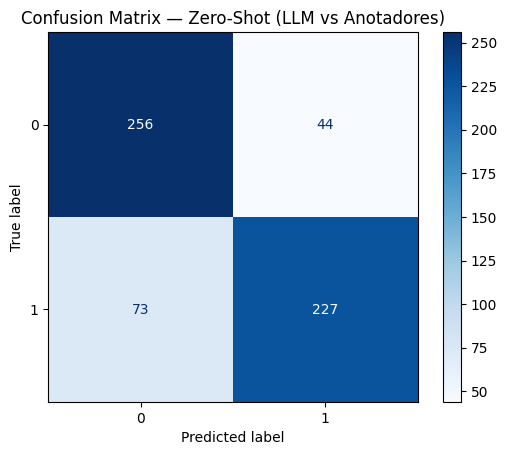


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.8051 ± 0.0166
Precision: 0.8374 ± 0.0225
Recall: 0.7575 ± 0.0247
F1: 0.7952 ± 0.0190
Auc: 0.8051 ± 0.0165


In [2]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/wpp/wpp_comparado_zeroShot.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)

# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Zero-Shot (LLM vs Anotadores)")
plt.savefig("./resultados/wpp/matriz_confusao_zero_shot.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/wpp/metricas_avaliacao_zeroShot_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


### Few Shot

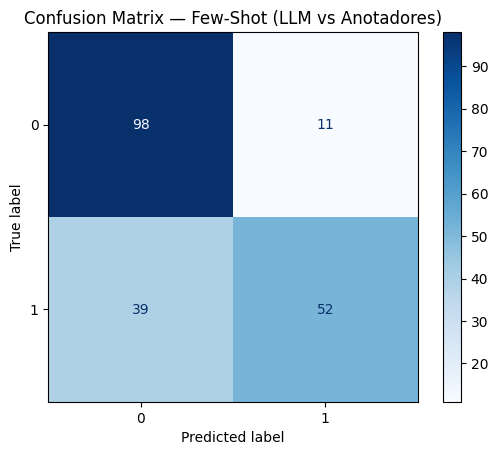


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.7502 ± 0.0305
Precision: 0.8249 ± 0.0484
Recall: 0.5709 ± 0.0524
F1: 0.6733 ± 0.0442
Auc: 0.7351 ± 0.0299


In [3]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

# Lê o arquivo combinado
df = pd.read_csv("./resultados/wpp/wpp_comparado_fewShot.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)


# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Few-Shot (LLM vs Anotadores)")
plt.savefig("./resultados/wpp/matriz_confusao_few_shot.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/wpp/metricas_avaliacao_fewShot_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


### Role prompting

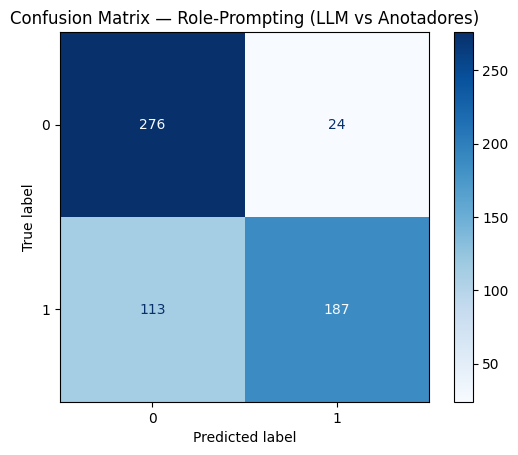


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.7712 ± 0.0173
Precision: 0.8855 ± 0.0212
Recall: 0.6233 ± 0.0279
F1: 0.7313 ± 0.0223
Auc: 0.7713 ± 0.0162


In [4]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/wpp/wpp_comparado_role_prompting.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)


# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Role-Prompting (LLM vs Anotadores)")
plt.savefig("./resultados/wpp/matriz_confusao_role_prompting.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/wpp/metricas_avaliacao_role_prompting_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")


### Role + Dic

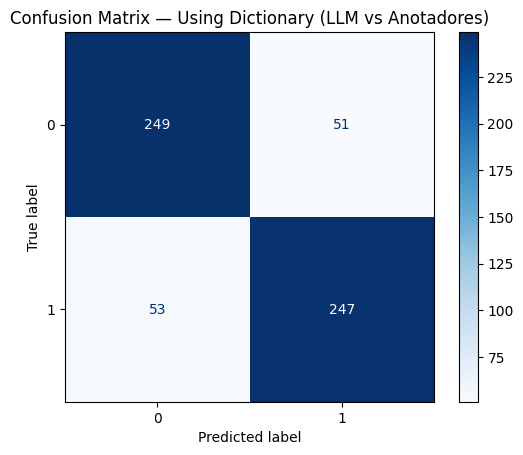


 Resultados de avaliação (média ± desvio padrão):
Accuracy: 0.8262 ± 0.0160
Precision: 0.8284 ± 0.0218
Recall: 0.8233 ± 0.0221
F1: 0.8256 ± 0.0173
Auc: 0.8262 ± 0.0160


In [5]:

# Lê o arquivo combinado
df = pd.read_csv("./resultados/wpp/wpp_comparado_role_prompting_dic.csv")

# Converte as colunas para inteiro
df["preconceito"] = pd.to_numeric(df["preconceito"], errors="coerce")
df["rotulo_chatgpt"] = pd.to_numeric(df["rotulo_chatgpt"], errors="coerce")

# Remove linhas com valores ausentes
df = df.dropna(subset=["preconceito", "rotulo_chatgpt"])

y_true = df["preconceito"].values
y_pred = df["rotulo_chatgpt"].values

# Parâmetros do bootstrap
n_bootstrap = 1000  # número de repetições
rng = np.random.default_rng(42)

# Armazena métricas de cada repetição
metrics = {
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": []
}

for _ in range(n_bootstrap):
    idx = rng.integers(0, len(y_true), len(y_true))
    y_true_sample = y_true[idx]
    y_pred_sample = y_pred[idx]

    metrics["accuracy"].append(accuracy_score(y_true_sample, y_pred_sample))
    metrics["precision"].append(precision_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["recall"].append(recall_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["f1"].append(f1_score(y_true_sample, y_pred_sample, zero_division=0))
    metrics["auc"].append(roc_auc_score(y_true_sample, y_pred_sample))

# Calcula média e desvio padrão
resultados = {m: (np.mean(vals), np.std(vals)) for m, vals in metrics.items()}

# --- Matriz de confusão ---
cm = confusion_matrix(y_true, y_pred)


# --- Visualização da matriz ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Using Dictionary (LLM vs Anotadores)")
plt.savefig("./resultados/wpp/matriz_confusao_role_prompting_dic.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n Resultados de avaliação (média ± desvio padrão):")
for m, (media, desvio) in resultados.items():
    print(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}")

# Salva os resultados
with open("./resultados/wpp/metricas_avaliacao_role_prompting_dic_bootstrap.txt", "w", encoding="utf-8") as f:
    f.write(" MÉTRICAS DE AVALIAÇÃO COM BOOTSTRAP (LLM vs Anotadores)\n\n")
    f.write(f"Total de exemplos avaliados: {len(df)}\n")
    for m, (media, desvio) in resultados.items():
        f.write(f"{m.capitalize()}: {media:.4f} ± {desvio:.4f}\n")
